# UK river network and the Thames extract

Loads the OS Open Rivers (Great Britain) watercourse network and extracts the River Thames from it, then plots both: the full GB network for context, and the Thames on its own.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
from geoalchemy2.shape import to_shape
from sqlmodel import Session

from wxdecide.database.engine import get_engine
from wxdecide.database.queries import connected_river_links

%matplotlib inline

## Full GB river network

In [2]:
# geopandas/GDAL can read the gzipped GeoJSON directly via the /vsigzip/ virtual filesystem
rivers = gpd.read_file("/vsigzip/../data/os_open_rivers_gb.geojson.gz")
len(rivers)

193040

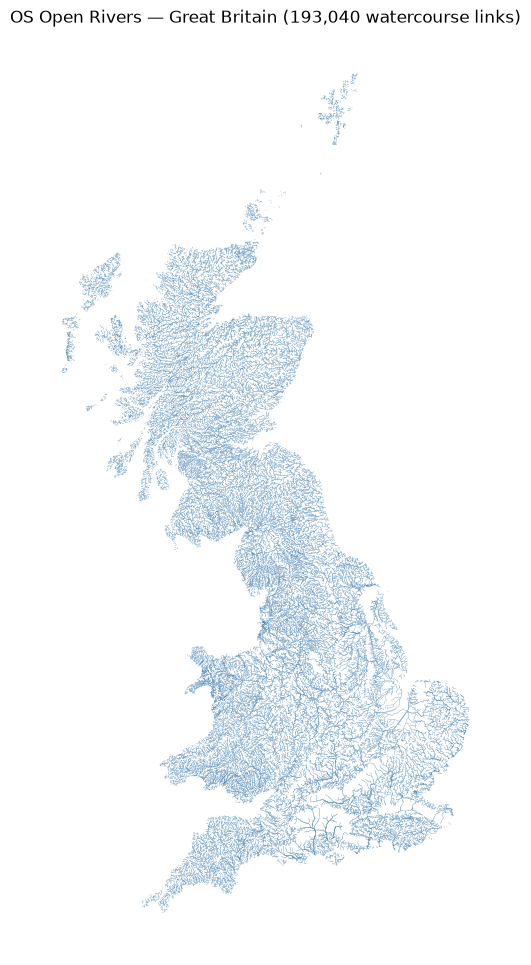

In [3]:
fig, ax = plt.subplots(figsize=(8, 12))
rivers.plot(ax=ax, linewidth=0.2, color="steelblue")
ax.set_title(f"OS Open Rivers — Great Britain ({len(rivers):,} watercourse links)")
ax.set_axis_off()

## River Thames extract

OS Open Rivers doesn't tag every Thames link with `watercourse_name == "River Thames"` — many reaches between locks carry a local pool/reach name instead (e.g. *Sonning Reach*, *Sandford Pool*, *Upper Pool*) and only record "River Thames" in `watercourse_name_alternative`. On top of that, the network has small real gaps at locks, weirs and wide tidal stretches — most visible in the tidal reach through London and out to the estuary — where the linework doesn't join up node-to-node.

So a naive `watercourse_name == "River Thames"` filter comes out fragmented (dashes rather than a continuous line, worst towards the estuary). Rather than re-deriving that fix here in pandas, this pulls the already-fixed result straight from Postgres/PostGIS via `wxdecide.database.queries.connected_river_links` — the same SQLAlchemy query backing the `river_thames_connected` view (see the `index river_links nodes and add connected thames view` migration). It:
1. Matches on `watercourse_name` **or** `watercourse_name_alternative` to pick up the reach-named links.
2. Flood-fills through short (<=1000m) *unnamed* connector links to bridge the remaining lock/weir/tidal gaps, without pulling in real named tributaries.

This assumes the local Postgres is up and `river_links` has been seeded — see `wxdecide.database.seed_rivers`:

```bash
docker compose up -d postgres
uv run alembic upgrade head
uv run python -m wxdecide.database.seed_rivers
```

In [4]:
with Session(get_engine()) as session:
    thames_links = connected_river_links(session, "River Thames")

thames = gpd.GeoDataFrame(
    [
        {
            "id": link.id,
            "watercourse_name": link.watercourse_name,
            "watercourse_name_alternative": link.watercourse_name_alternative,
            "form": link.form,
            "length": link.length,
            "start_node": link.start_node,
            "end_node": link.end_node,
            "geometry": to_shape(link.geometry),
        }
        for link in thames_links
    ],
    crs="EPSG:4326",
)
print(f"{len(thames)} links fetched from Postgres via connected_river_links()")

527 links fetched from Postgres via connected_river_links()


In [5]:
# sanity check: how many disconnected pieces remain?
graph = nx.Graph()
for _, row in thames.iterrows():
    graph.add_edge(row["start_node"], row["end_node"])
components = sorted(nx.connected_components(graph), key=len, reverse=True)
print(f"{len(components)} connected component(s), sizes: {[len(c) for c in components]}")

3 connected component(s), sizes: [371, 129, 24]


In [6]:
thames.to_file("../data/river_thames.geojson", driver="GeoJSON")
len(thames)

527

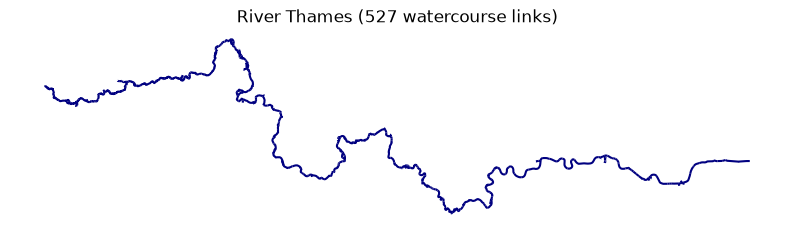

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
thames.plot(ax=ax, linewidth=1.5, color="navy")
ax.set_title(f"River Thames ({len(thames)} watercourse links)")
ax.set_axis_off()

## Thames highlighted within the full network

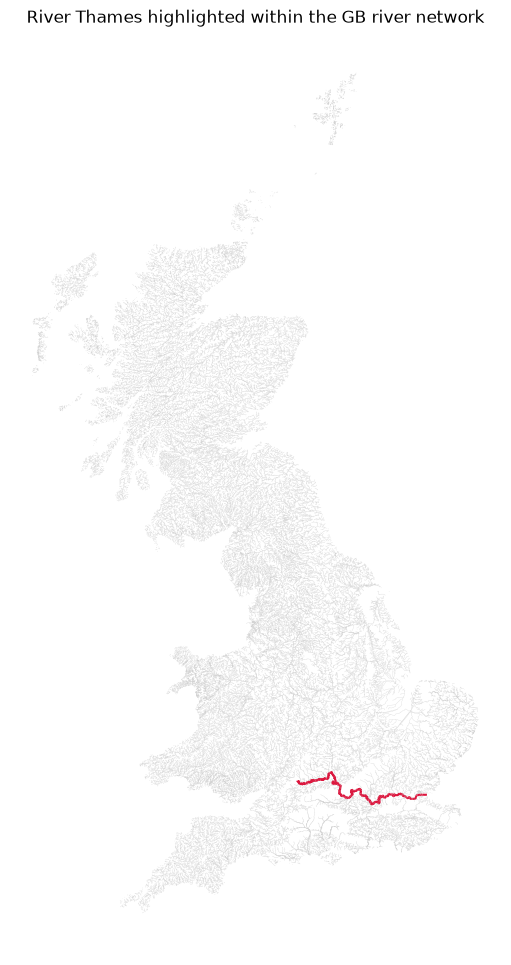

In [8]:
fig, ax = plt.subplots(figsize=(8, 12))
rivers.plot(ax=ax, linewidth=0.2, color="lightgrey")
thames.plot(ax=ax, linewidth=1.5, color="crimson")
ax.set_title("River Thames highlighted within the GB river network")
ax.set_axis_off()